# Module 1.5: Finite Difference Method — Why Derivatives Aren't Continuous

**Goal:** Understand how we approximate derivatives numerically, why different approaches give different answers, and how accuracy improves with grid refinement.

This is the **foundation** of all CFD discretization. Every PDE solver you'll ever write uses finite differences (or something built on the same idea).

## 1. Import Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Make plots look nice
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 2

## 2. Define Sample Data Points

Let's start with the exact example you worked out by hand:
- $(x_0, y_0) = (0, 2)$
- $(x_1, y_1) = (1, 5)$
- $(x_2, y_2) = (2, 10)$

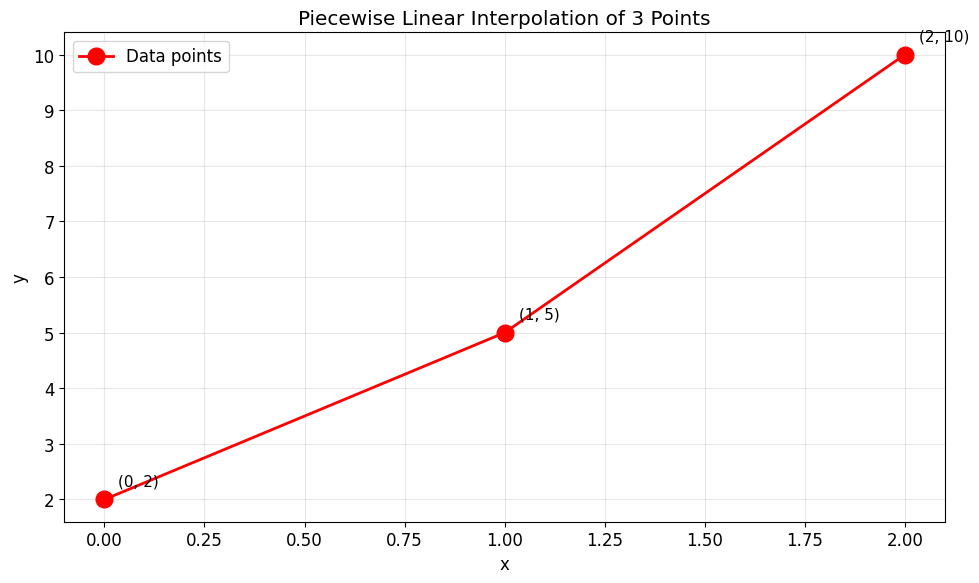

In [2]:
# Our three data points
x = np.array([0.0, 1.0, 2.0])
y = np.array([2.0, 5.0, 10.0])

# Plot the piecewise linear interpolation
fig, ax = plt.subplots()
ax.plot(x, y, 'ro-', markersize=12, label='Data points')
for i in range(len(x)):
    ax.annotate(f'({x[i]:.0f}, {y[i]:.0f})', (x[i], y[i]),
                textcoords="offset points", xytext=(10, 10), fontsize=11)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Piecewise Linear Interpolation of 3 Points')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Compute Finite Difference Derivatives at x = 1

Three ways to estimate $y'$ at $x = 1$:

| Method | Formula | Interval Used |
|--------|---------|---------------|
| **Backward** | $\frac{y_1 - y_0}{x_1 - x_0}$ | $[0, 1]$ |
| **Forward** | $\frac{y_2 - y_1}{x_2 - x_1}$ | $[1, 2]$ |
| **Central** | $\frac{y_2 - y_0}{x_2 - x_0}$ | $[0, 2]$ |

In [3]:
# Backward difference: using points (0,2) and (1,5)
dy_backward = (y[1] - y[0]) / (x[1] - x[0])

# Forward difference: using points (1,5) and (2,10)
dy_forward = (y[2] - y[1]) / (x[2] - x[1])

# Central difference: using points (0,2) and (2,10)
dy_central = (y[2] - y[0]) / (x[2] - x[0])

print("=" * 50)
print("Finite Difference Derivatives at x = 1")
print("=" * 50)
print(f"Backward difference:  y' = ({y[1]} - {y[0]}) / ({x[1]} - {x[0]}) = {dy_backward}")
print(f"Forward difference:   y' = ({y[2]} - {y[1]}) / ({x[2]} - {x[1]}) = {dy_forward}")
print(f"Central difference:   y' = ({y[2]} - {y[0]}) / ({x[2]} - {x[0]}) = {dy_central}")
print()
print(f"Three different answers: {dy_backward}, {dy_forward}, {dy_central}")
print(f"Central = average of backward and forward: ({dy_backward} + {dy_forward})/2 = {(dy_backward + dy_forward)/2}")

Finite Difference Derivatives at x = 1
Backward difference:  y' = (5.0 - 2.0) / (1.0 - 0.0) = 3.0
Forward difference:   y' = (10.0 - 5.0) / (2.0 - 1.0) = 5.0
Central difference:   y' = (10.0 - 2.0) / (2.0 - 0.0) = 4.0

Three different answers: 3.0, 5.0, 4.0
Central = average of backward and forward: (3.0 + 5.0)/2 = 4.0


## 4. Visualize the Slopes at x = 1

Let's overlay tangent lines at $x = 1$ using each slope to **see** how different they are:

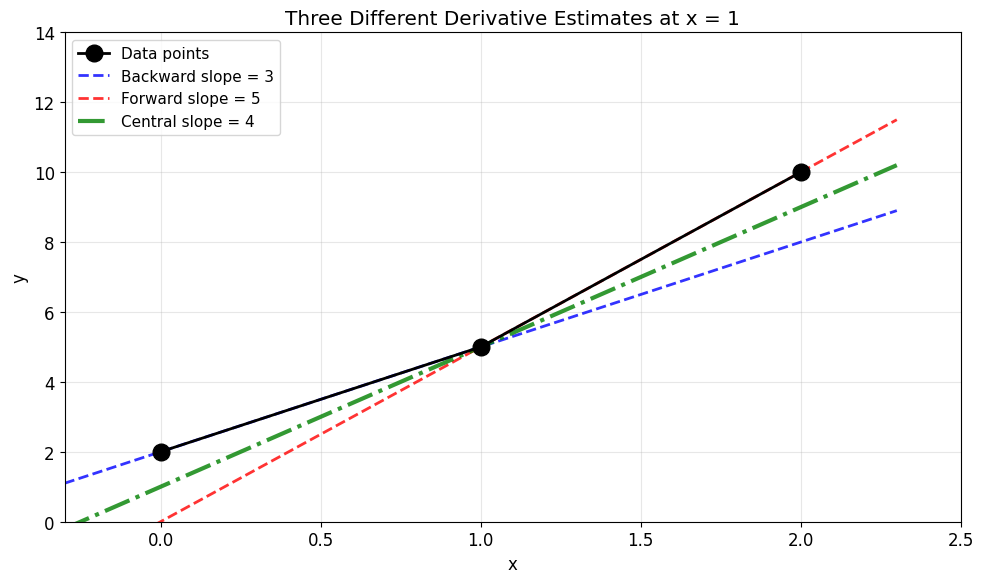

In [4]:
fig, ax = plt.subplots()

# Plot data points and connecting lines
ax.plot(x, y, 'ko-', markersize=12, label='Data points', zorder=5)

# Tangent lines at x=1 using each slope (y - y1 = slope * (x - x1))
x_tangent = np.linspace(-0.3, 2.3, 100)
x1, y1 = 1.0, 5.0

ax.plot(x_tangent, y1 + dy_backward * (x_tangent - x1), 'b--',
        label=f'Backward slope = {dy_backward:.0f}', alpha=0.8)
ax.plot(x_tangent, y1 + dy_forward * (x_tangent - x1), 'r--',
        label=f'Forward slope = {dy_forward:.0f}', alpha=0.8)
ax.plot(x_tangent, y1 + dy_central * (x_tangent - x1), 'g-.',
        label=f'Central slope = {dy_central:.0f}', linewidth=3, alpha=0.8)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Three Different Derivative Estimates at x = 1')
ax.set_xlim(-0.3, 2.5)
ax.set_ylim(0, 14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. The Derivative is Discontinuous!

The piecewise linear function has slope = 3 on $[0, 1)$ and slope = 5 on $[1, 2)$. At $x = 1$ there is a **jump discontinuity** in the derivative:

$$\lim_{x \to 1^-} y' = 3 \neq 5 = \lim_{x \to 1^+} y'$$

This is exactly what you observed: "the changes are not continuous."

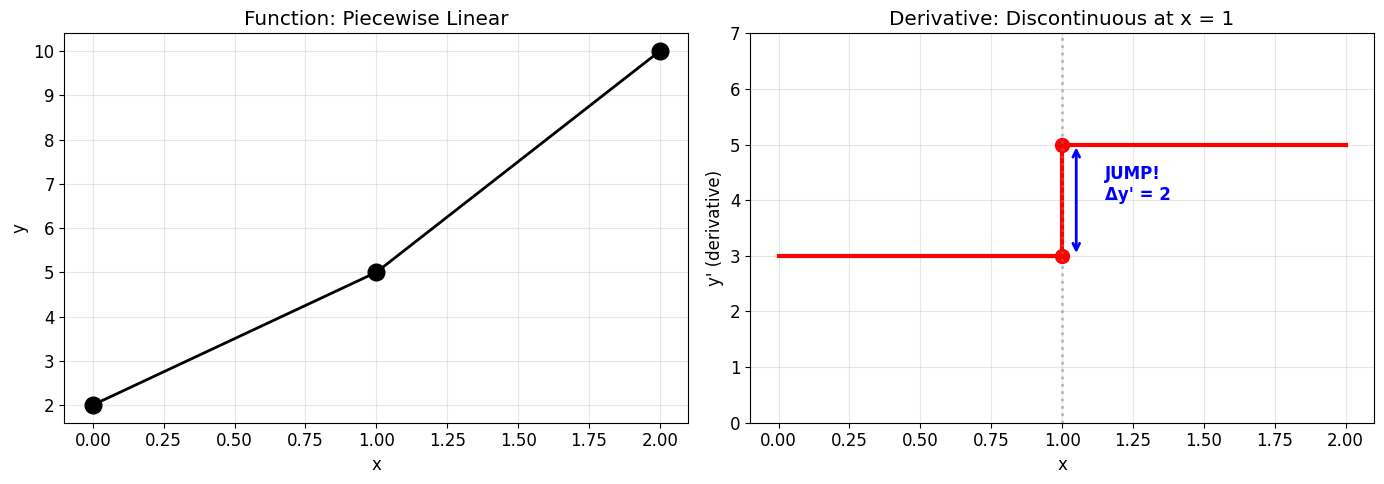

Left-hand derivative at x=1:  lim(x→1⁻) y' = 3
Right-hand derivative at x=1: lim(x→1⁺) y' = 5
Central difference estimate:  y' = 4 (average)

The derivative is NOT continuous — this is the nature of finite differences!


In [5]:
# Plot derivative as a step function
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: original function
axes[0].plot(x, y, 'ko-', markersize=12)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Function: Piecewise Linear')
axes[0].grid(True, alpha=0.3)

# Right: derivative (step function)
# Slope on [0,1) = 3, slope on [1,2) = 5
x_deriv = [0, 1, 1, 2]
y_deriv = [3, 3, 5, 5]
axes[1].plot(x_deriv, y_deriv, 'r-', linewidth=3)
axes[1].plot([1], [3], 'ro', markersize=10)  # left limit (filled)
axes[1].plot([1], [5], 'ro', markersize=10)  # right limit (filled)

# Annotate the jump
axes[1].annotate('', xy=(1.05, 5), xytext=(1.05, 3),
                arrowprops=dict(arrowstyle='<->', color='blue', lw=2))
axes[1].text(1.15, 4, 'JUMP!\nΔy\' = 2', fontsize=12, color='blue', fontweight='bold')
axes[1].axvline(x=1, color='gray', linestyle=':', alpha=0.5)

axes[1].set_xlabel('x')
axes[1].set_ylabel("y' (derivative)")
axes[1].set_title("Derivative: Discontinuous at x = 1")
axes[1].set_ylim(0, 7)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Left-hand derivative at x=1:  lim(x→1⁻) y' = 3")
print("Right-hand derivative at x=1: lim(x→1⁺) y' = 5")
print("Central difference estimate:  y' = 4 (average)")
print("\nThe derivative is NOT continuous — this is the nature of finite differences!")

## 6. Compare All Three Finite Difference Methods

| Method | Formula | Order of Accuracy | Our Result |
|--------|---------|-------------------|-----------|
| Backward | $\frac{f(x) - f(x - \Delta x)}{\Delta x}$ | $O(\Delta x)$ — 1st order | 3 |
| Forward | $\frac{f(x + \Delta x) - f(x)}{\Delta x}$ | $O(\Delta x)$ — 1st order | 5 |
| **Central** | $\frac{f(x + \Delta x) - f(x - \Delta x)}{2\Delta x}$ | $O(\Delta x^2)$ — **2nd order** | **4** |

The central difference is the **average** of backward and forward — and it's one order more accurate!

In [6]:
def forward_diff(f, x, dx):
    """Forward difference: f'(x) ≈ [f(x+dx) - f(x)] / dx"""
    return (f(x + dx) - f(x)) / dx

def backward_diff(f, x, dx):
    """Backward difference: f'(x) ≈ [f(x) - f(x-dx)] / dx"""
    return (f(x) - f(x - dx)) / dx

def central_diff(f, x, dx):
    """Central difference: f'(x) ≈ [f(x+dx) - f(x-dx)] / (2*dx)"""
    return (f(x + dx) - f(x - dx)) / (2 * dx)

# Verify with our data: f(x) = x^2 + 2x + 2 passes through all 3 points
f = lambda x: x**2 + 2*x + 2       # f(0)=2, f(1)=5, f(2)=10 ✓
f_exact = lambda x: 2*x + 2         # Exact derivative

x_eval = 1.0
dx = 1.0

print("Using f(x) = x² + 2x + 2,  f'(x) = 2x + 2")
print(f"Exact derivative at x={x_eval}: f'({x_eval}) = {f_exact(x_eval)}")
print()
print(f"Backward difference: {backward_diff(f, x_eval, dx):.4f}  (error = {abs(backward_diff(f, x_eval, dx) - f_exact(x_eval)):.4f})")
print(f"Forward difference:  {forward_diff(f, x_eval, dx):.4f}  (error = {abs(forward_diff(f, x_eval, dx) - f_exact(x_eval)):.4f})")
print(f"Central difference:  {central_diff(f, x_eval, dx):.4f}  (error = {abs(central_diff(f, x_eval, dx) - f_exact(x_eval)):.4f})")
print()
print("Central difference gives EXACT answer for this quadratic — because it's 2nd order accurate!")

Using f(x) = x² + 2x + 2,  f'(x) = 2x + 2
Exact derivative at x=1.0: f'(1.0) = 4.0

Backward difference: 3.0000  (error = 1.0000)
Forward difference:  5.0000  (error = 1.0000)
Central difference:  4.0000  (error = 0.0000)

Central difference gives EXACT answer for this quadratic — because it's 2nd order accurate!


## 7. Convergence Study — Proof That Finer Grid = Better Accuracy

The real power of finite differences: as $\Delta x \to 0$, the approximation converges to the true derivative.

Let's test with $f(x) = \sin(x)$ where we know $f'(x) = \cos(x)$ exactly. We'll measure the error at $x = 1$ for decreasing $\Delta x$ values.

        Δx |  Forward err | Backward err |  Central err
-------------------------------------------------------
  1.000000 |     4.72e-01 |     3.01e-01 |     8.57e-02
  0.500000 |     2.28e-01 |     1.84e-01 |     2.22e-02
  0.250000 |     1.10e-01 |     9.90e-02 |     5.61e-03
  0.125000 |     5.39e-02 |     5.11e-02 |     1.41e-03
  0.062500 |     2.66e-02 |     2.59e-02 |     3.52e-04
  0.031250 |     1.32e-02 |     1.31e-02 |     8.79e-05
  0.015625 |     6.60e-03 |     6.55e-03 |     2.20e-05


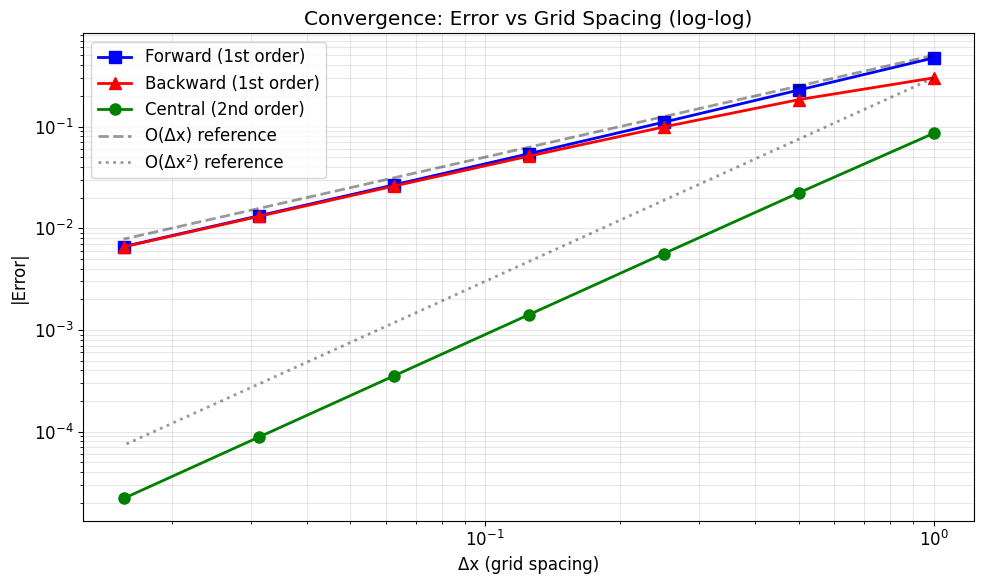


Key insight: On the log-log plot...
  Forward/Backward: slope ≈ 1 → error halves when Δx halves (1st order)
  Central:          slope ≈ 2 → error quarters when Δx halves (2nd order)


In [7]:
# Test function: f(x) = sin(x), f'(x) = cos(x)
f_test = np.sin
f_test_exact = np.cos

x_eval = 1.0
exact = f_test_exact(x_eval)

# Grid spacings from coarse to fine
dx_values = np.array([1.0, 0.5, 0.25, 0.125, 0.0625, 0.03125, 0.015625])

error_fwd = np.array([abs(forward_diff(f_test, x_eval, dx) - exact) for dx in dx_values])
error_bwd = np.array([abs(backward_diff(f_test, x_eval, dx) - exact) for dx in dx_values])
error_cen = np.array([abs(central_diff(f_test, x_eval, dx) - exact) for dx in dx_values])

# Print results table
print(f"{'Δx':>10} | {'Forward err':>12} | {'Backward err':>12} | {'Central err':>12}")
print("-" * 55)
for i, dx in enumerate(dx_values):
    print(f"{dx:10.6f} | {error_fwd[i]:12.2e} | {error_bwd[i]:12.2e} | {error_cen[i]:12.2e}")

# LOG-LOG CONVERGENCE PLOT
fig, ax = plt.subplots()

ax.loglog(dx_values, error_fwd, 'bs-', markersize=8, label='Forward (1st order)')
ax.loglog(dx_values, error_bwd, 'r^-', markersize=8, label='Backward (1st order)')
ax.loglog(dx_values, error_cen, 'go-', markersize=8, label='Central (2nd order)')

# Reference lines for O(dx) and O(dx^2)
ax.loglog(dx_values, 0.5 * dx_values, 'k--', alpha=0.4, label='O(Δx) reference')
ax.loglog(dx_values, 0.3 * dx_values**2, 'k:', alpha=0.4, label='O(Δx²) reference')

ax.set_xlabel('Δx (grid spacing)')
ax.set_ylabel('|Error|')
ax.set_title("Convergence: Error vs Grid Spacing (log-log)")
ax.legend()
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

print("\nKey insight: On the log-log plot...")
print("  Forward/Backward: slope ≈ 1 → error halves when Δx halves (1st order)")
print("  Central:          slope ≈ 2 → error quarters when Δx halves (2nd order)")

## 8. Full Array Derivative — Visual Proof of Convergence

Let's compute the numerical derivative of $\sin(x)$ across the entire domain $[0, 2\pi]$ at different resolutions.  
As we add more points, the numerical derivative approaches the true $\cos(x)$.

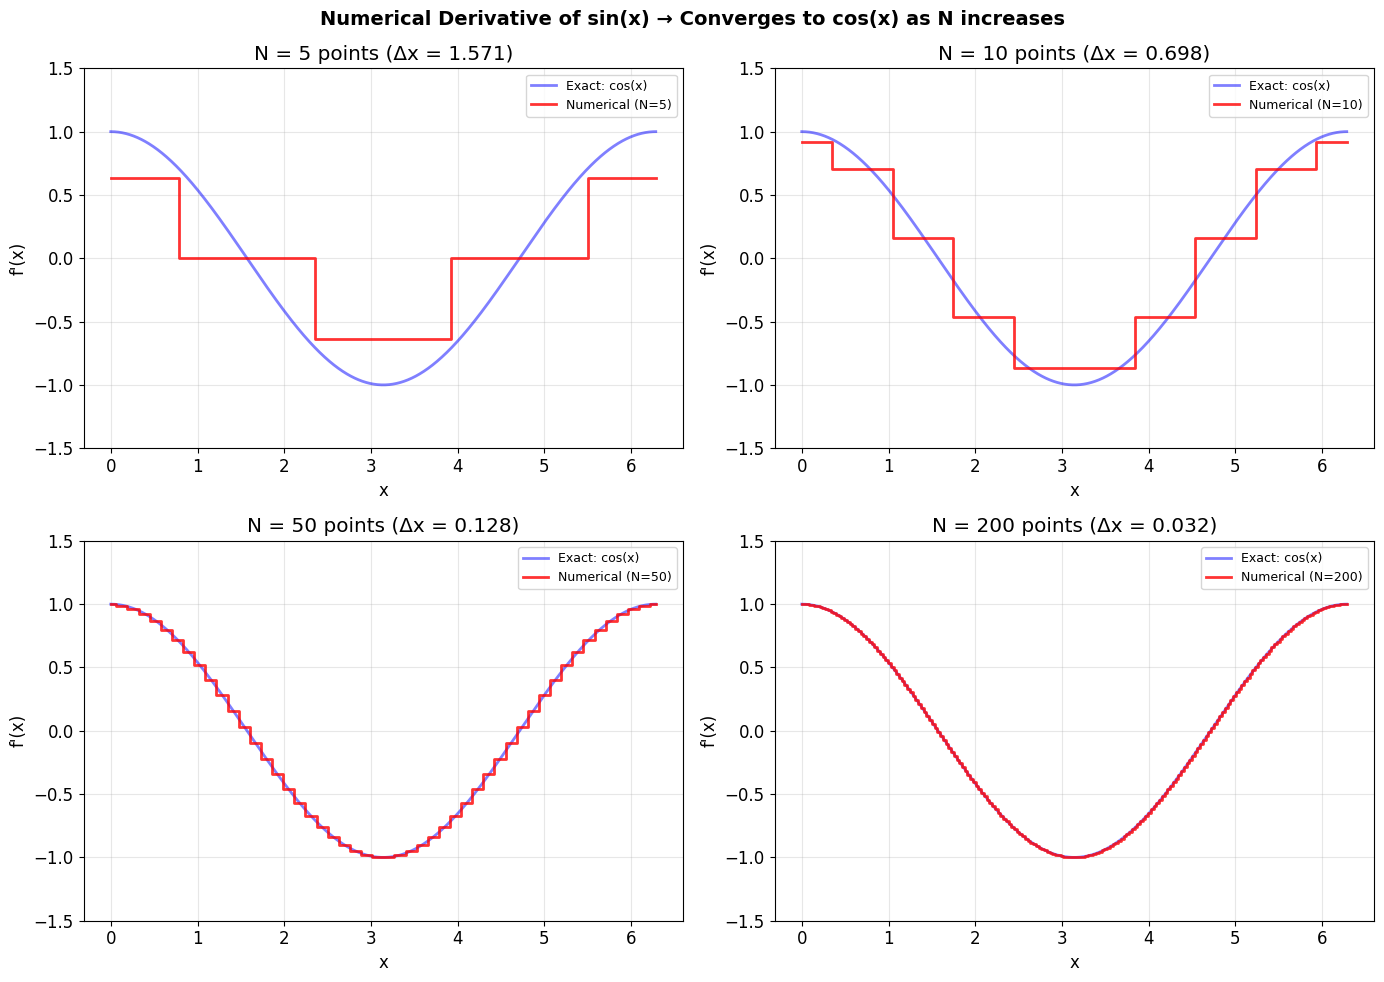

As Δx → 0 (more points), the step-like numerical derivative
converges toward the smooth analytical derivative cos(x).


In [8]:
# Compare numerical derivatives at different resolutions
resolutions = [5, 10, 50, 200]
x_exact = np.linspace(0, 2 * np.pi, 1000)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, N in enumerate(resolutions):
    ax = axes[idx]
    x_grid = np.linspace(0, 2 * np.pi, N)
    y_grid = np.sin(x_grid)
    dx = x_grid[1] - x_grid[0]

    # Central difference for interior points
    dy_numerical = np.zeros_like(y_grid)
    dy_numerical[0] = (y_grid[1] - y_grid[0]) / dx                       # Forward at left boundary
    dy_numerical[-1] = (y_grid[-1] - y_grid[-2]) / dx                    # Backward at right boundary
    dy_numerical[1:-1] = (y_grid[2:] - y_grid[:-2]) / (2 * dx)          # Central for interior

    # Plot
    ax.plot(x_exact, np.cos(x_exact), 'b-', alpha=0.5, label='Exact: cos(x)')
    ax.step(x_grid, dy_numerical, 'r-', where='mid', alpha=0.8, label=f'Numerical (N={N})')
    ax.set_title(f'N = {N} points (Δx = {dx:.3f})')
    ax.set_xlabel('x')
    ax.set_ylabel("f'(x)")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-1.5, 1.5)

plt.suptitle("Numerical Derivative of sin(x) → Converges to cos(x) as N increases",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("As Δx → 0 (more points), the step-like numerical derivative")
print("converges toward the smooth analytical derivative cos(x).")

## Key Takeaways

1. **Finite differences approximate derivatives** using nearby function values — they are never exact (unless the function is a polynomial of the right degree)
2. **Three schemes:** Forward, Backward, Central — each uses different neighboring points
3. **Central difference is best** for the same grid spacing (2nd order vs 1st order)
4. **Numerical derivatives are piecewise constant** (step functions) — inherently discontinuous
5. **Convergence:** As $\Delta x \to 0$, the approximation approaches the true derivative
6. **In CFD:** Every $\frac{\partial u}{\partial x}$ in the Navier-Stokes equations gets replaced by one of these formulas!

### What's Connecting to CFD:
```
Navier-Stokes:   u * ∂u/∂x                    →  u[i] * (u[i+1] - u[i-1]) / (2*dx)
                 ∂²u/∂x²                       →  (u[i+1] - 2*u[i] + u[i-1]) / dx²
                 ∂p/∂x                          →  (p[i+1] - p[i-1]) / (2*dx)
```
This is exactly how we do it. Next up: we'll apply these to solve actual PDEs!